<a href="https://colab.research.google.com/github/Munaza-maker12/neurofive-ml-track/blob/main/House_Price_Prediction_with_Linear_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

In [4]:
url = "https://raw.githubusercontent.com/ageron/handson-ml2/master/datasets/housing/housing.csv"
df = pd.read_csv(url)
df = df.dropna()

In [5]:
print("Dataset shape:", df.shape)
df.head()

Dataset shape: (20433, 10)


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [6]:
df["rooms_per_household"] = df["total_rooms"] / df["households"]
df["population_per_household"] = df["population"] / df["households"]

print(df.columns.tolist())

['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income', 'median_house_value', 'ocean_proximity', 'rooms_per_household', 'population_per_household']


In [7]:
selected_features = [
    "median_income",
    "housing_median_age",
    "rooms_per_household",
    "population_per_household",
    "latitude",
]

X = df[selected_features]
y = df["median_house_value"] / 100000  # readability ke liye $100,000 units mein

print(X.head())
print(y.head())

   median_income  housing_median_age  rooms_per_household  \
0         8.3252                41.0             6.984127   
1         8.3014                21.0             6.238137   
2         7.2574                52.0             8.288136   
3         5.6431                52.0             5.817352   
4         3.8462                52.0             6.281853   

   population_per_household  latitude  
0                  2.555556     37.88  
1                  2.109842     37.86  
2                  2.802260     37.85  
3                  2.547945     37.85  
4                  2.181467     37.85  
0    4.526
1    3.585
2    3.521
3    3.413
4    3.422
Name: median_house_value, dtype: float64


In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 16346
Testing samples: 4087


In [9]:
model = LinearRegression()
model.fit(X_train, y_train)

print("Model training complete!")
print("Coefficients:", model.coef_)
print("Intercept:", model.intercept_)

Model training complete!
Coefficients: [ 0.43654433  0.01697253 -0.0207723  -0.00400384 -0.04628615]
Intercept: 1.6658109714998077


In [10]:
y_pred = model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"RMSE: {rmse:.4f}  (in units of $100,000)")
print(f"R^2 Score: {r2:.4f}")

RMSE: 0.8102  (in units of $100,000)
R^2 Score: 0.5200


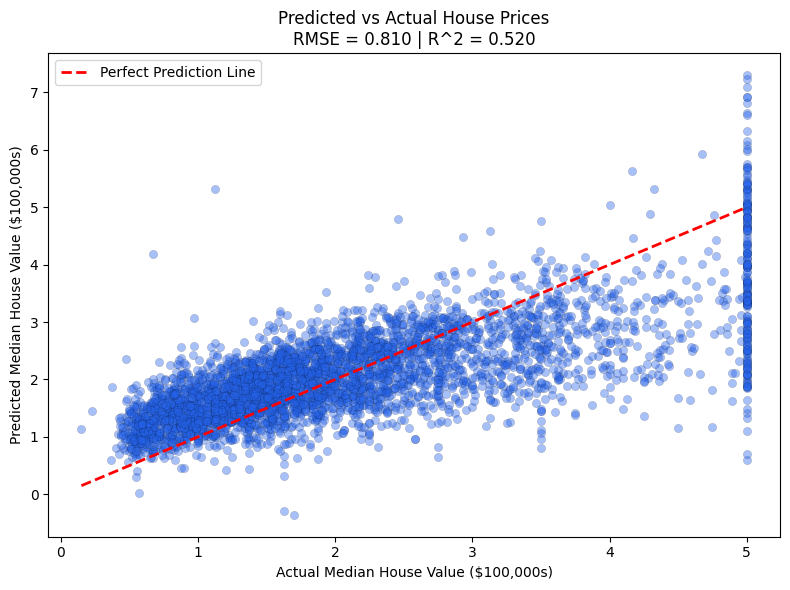

In [11]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.4, color="#2563eb", edgecolor="k", linewidth=0.2)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
         color="red", linestyle="--", linewidth=2, label="Perfect Prediction Line")
plt.xlabel("Actual Median House Value ($100,000s)")
plt.ylabel("Predicted Median House Value ($100,000s)")
plt.title(f"Predicted vs Actual House Prices\nRMSE = {rmse:.3f} | R^2 = {r2:.3f}")
plt.legend()
plt.tight_layout()
plt.show()